In [330]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

temp = pd.read_csv("../../data/07_portfolios_metadata/all_tickers_complete_metadata.csv").replace({
    "#ERROR!": np.nan
})

port_dict = {}
centralities = ["central", "peripheral"]
modes = ["fast", "medium", "slow"]

for mode in modes:
    for centrality in centralities:
        port_dict[f"{centrality}_{mode}"] = pd.read_csv(f"../../data/07_portfolios_metadata/{centrality}_{mode}_metadata.csv")[["Ticker", "Country"]].merge(
            temp, on="Ticker", how="inner"
        )

dfs = []

for portfolio_name, df in port_dict.items():
    df = df.copy()
    df["portfolio"] = portfolio_name.replace("_", " ")
    dfs.append(df)

final_df = pd.concat(dfs, ignore_index=True)
beta_df = pd.read_csv("../../data/07_portfolios_metadata/beta_df.csv")
final_df = final_df.merge(beta_df, on=["Ticker", "portfolio"], how="left")

year = 2019
cols_to_clean = [col_year for col_year in final_df.columns[5:] if str(year) in col_year]

final_df[cols_to_clean] = (
    final_df[cols_to_clean]
        .apply(lambda s: s.astype(str).str.replace(",", ".", regex=False))
)

final_df[cols_to_clean] = final_df[cols_to_clean].apply(
    pd.to_numeric, errors="coerce"
)

cols_to_keep = ["Ticker", "Country", "Company", "Sector",
                "Industry", "portfolio"] + cols_to_clean
final_df = final_df[cols_to_keep]

for col in cols_to_clean:
    final_df[f"{col}_cut"] = pd.qcut(
        final_df[col],
        q=6,
        duplicates="drop"
    )

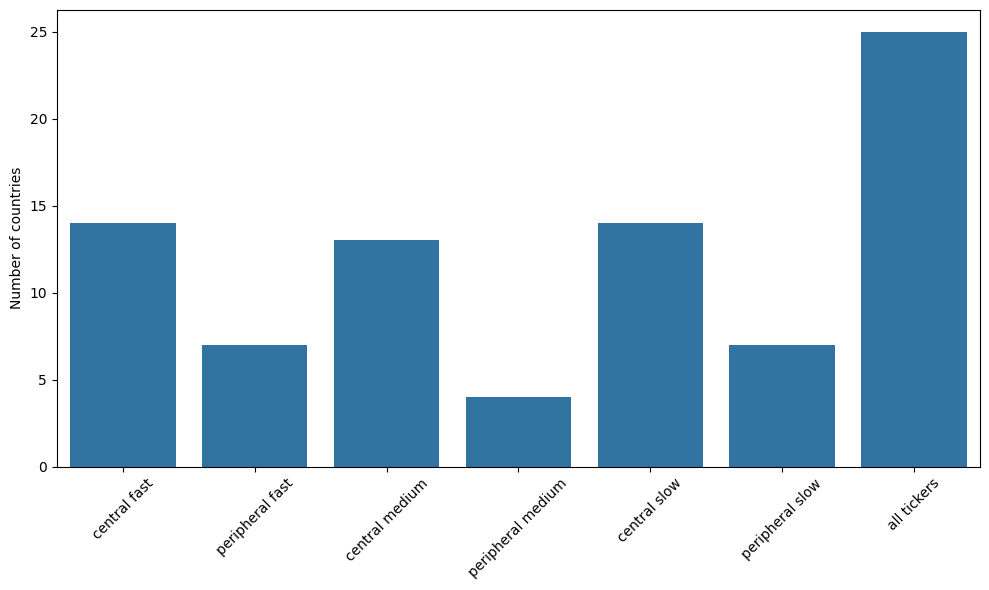

In [331]:
portfolios = final_df["portfolio"].unique()
temp = pd.DataFrame(columns=["n_countries"], index=portfolios)

for i in range(len(portfolios)):
    temp.loc[portfolios[i]] = final_df[final_df["portfolio"]==portfolios[i]]["Country"].nunique()
temp.loc["all tickers"] = final_df["Country"].nunique()

plot_df = temp.reset_index().rename(
    columns={"index": "portfolio"}
)

fig = plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_df,
    x="portfolio",
    y="n_countries"
)

plt.xticks(rotation=45)
plt.xlabel("")
plt.ylabel("Number of countries")
plt.tight_layout()

out_dir = "../../figures"
dpi = 300
out_path = Path(out_dir)
out_path.mkdir(parents=True, exist_ok=True)

filename = f"country_barplot_{year}.png"
fig.savefig(out_path / filename, dpi=dpi, bbox_inches="tight")

plt.show()

## Sector

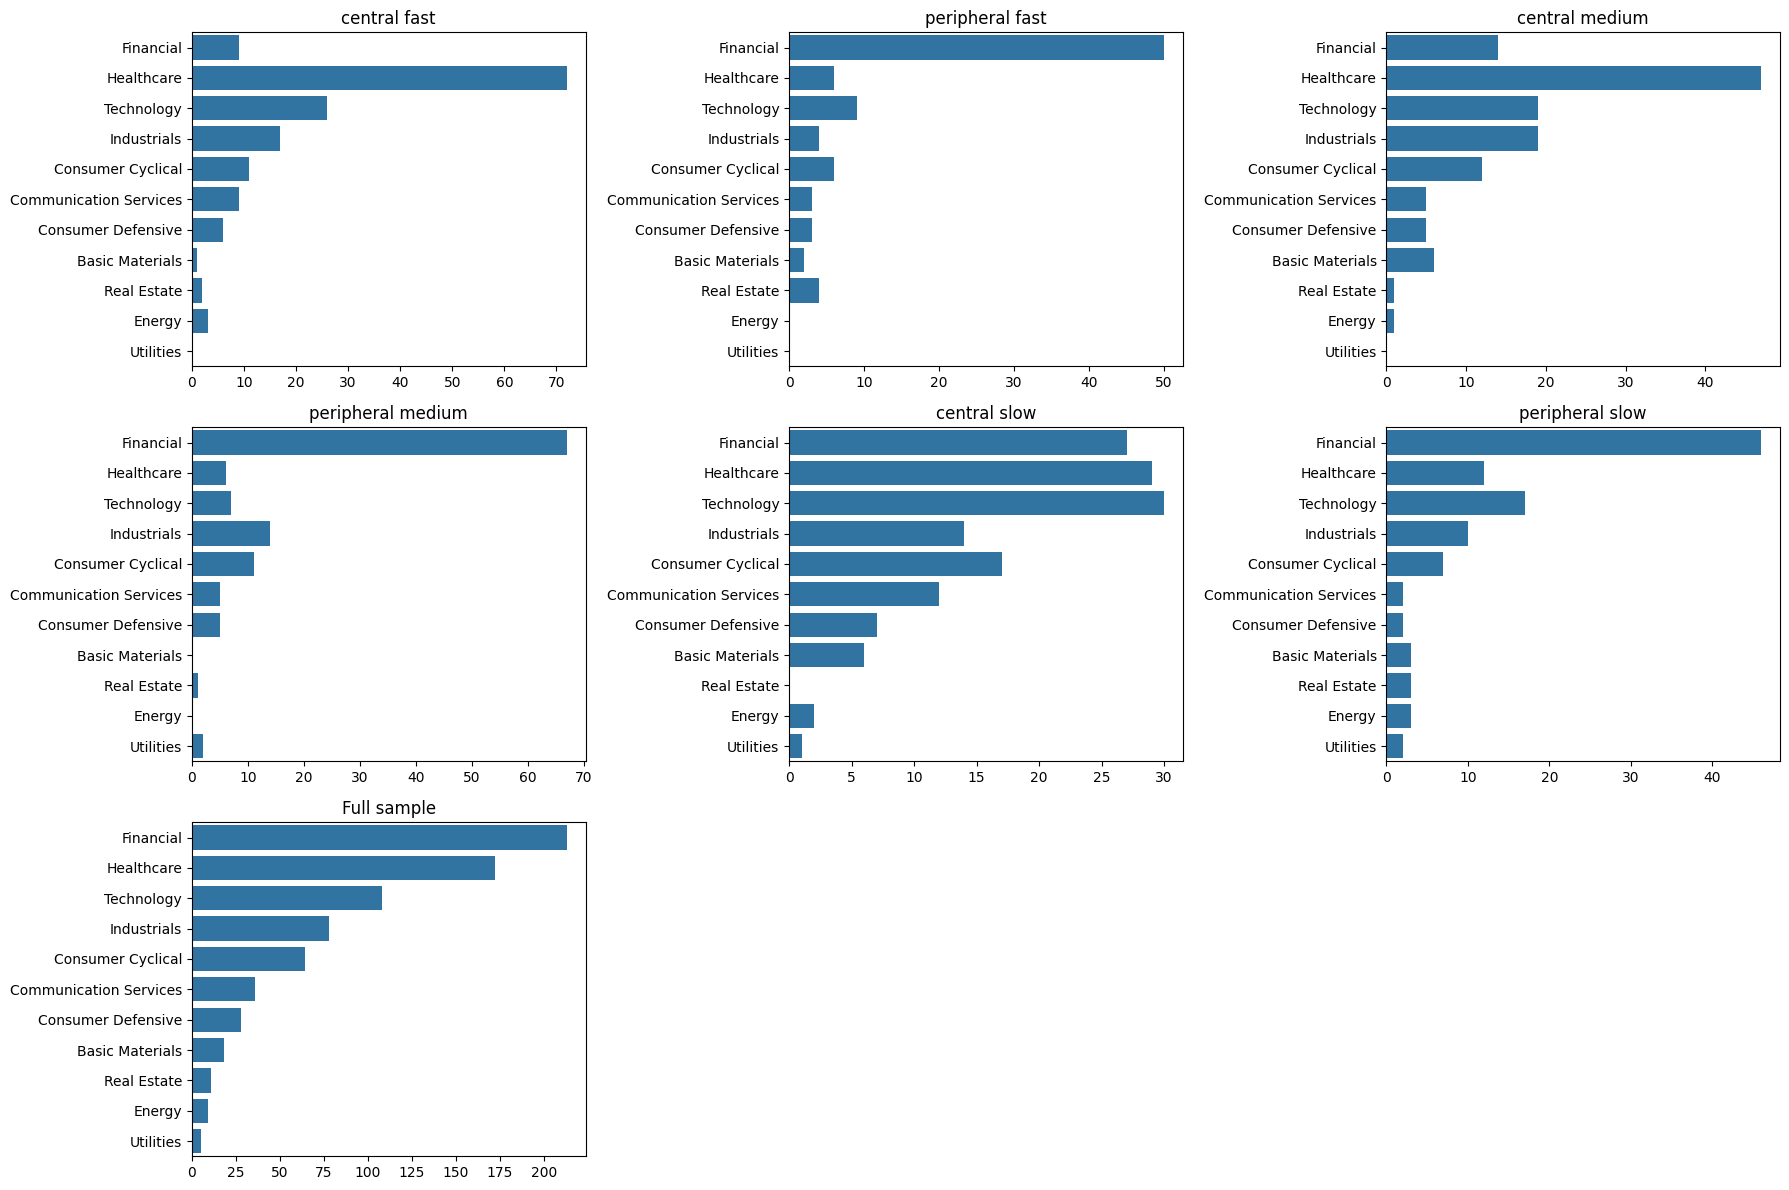

In [332]:
portfolios = final_df["portfolio"].unique()
plots = list(portfolios) + ["Full sample"]

n_cols = 3
n_rows = int(np.ceil(len(plots) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for ax, port in zip(axes, plots):
    if port == "Full sample":
        data = final_df
        title = "Full sample"
    else:
        data = final_df[final_df["portfolio"] == port]
        title = port

    sns.countplot(
        data=data,
        y="Sector",
        order=final_df["Sector"].value_counts().index,
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[len(plots):]:
    ax.axis("off")

plt.tight_layout()

out_dir = "../../figures"
dpi = 300
out_path = Path(out_dir)
out_path.mkdir(parents=True, exist_ok=True)

filename = f"sector_barplot_{year}.png"
fig.savefig(out_path / filename, dpi=dpi, bbox_inches="tight")

plt.show()

## Industry

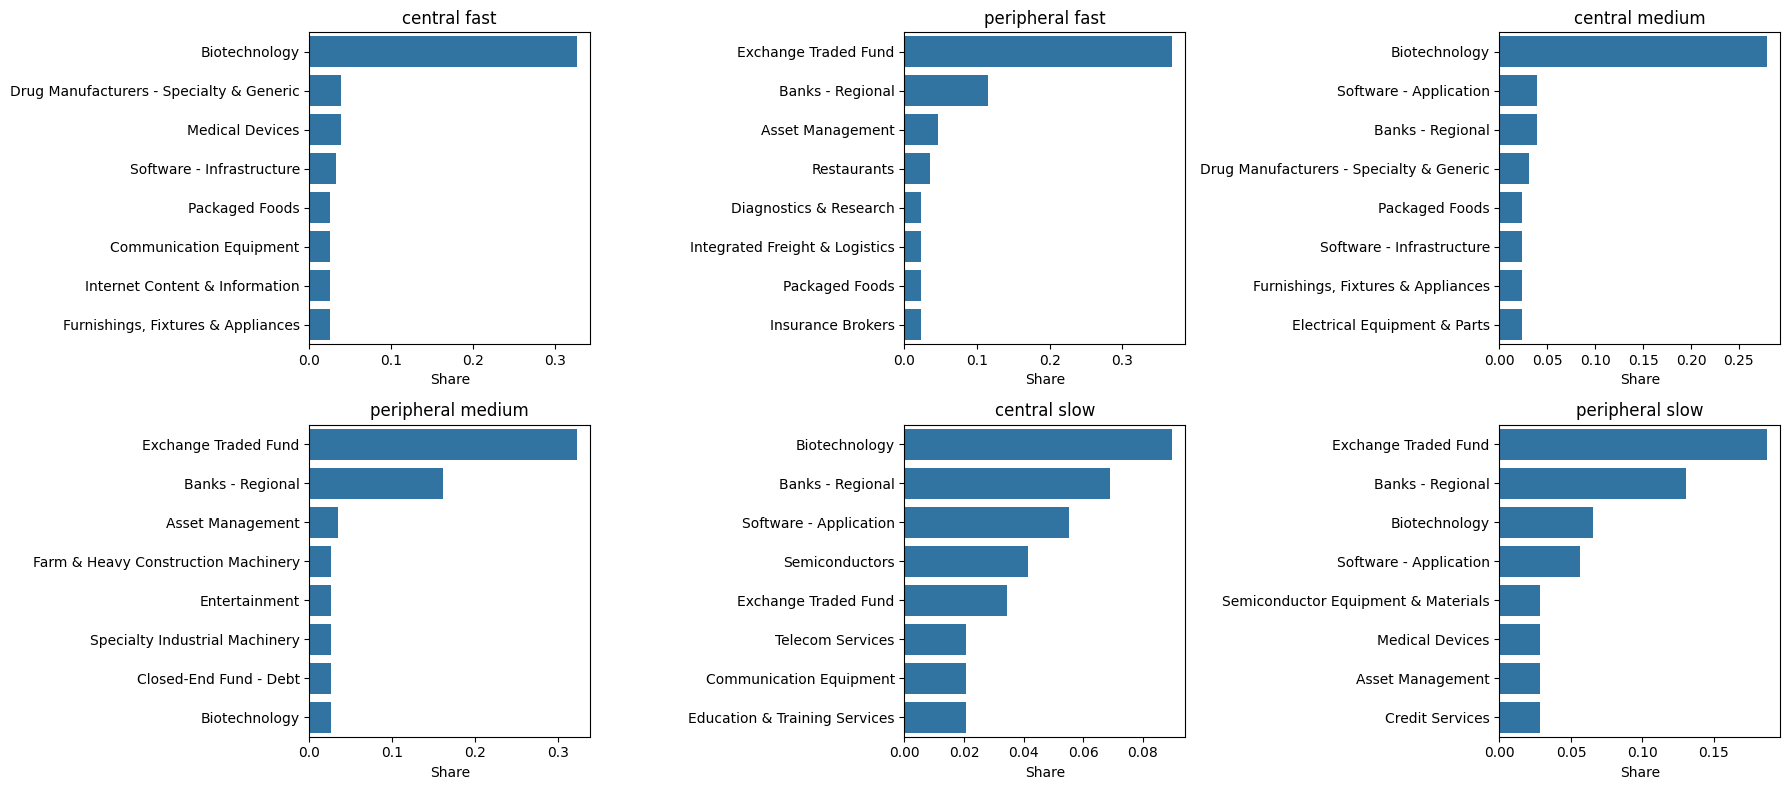

In [333]:
top_n = 8
portfolios = final_df["portfolio"].unique()

n_cols = 3
n_rows = int(np.ceil(len(portfolios) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for ax, port in zip(axes, portfolios):
    data = (
        final_df[final_df["portfolio"] == port]["Industry"]
        .value_counts(normalize=True)
        .head(top_n)
        .reset_index()
    )
    data.columns = ["Industry", "share"]

    sns.barplot(
        data=data,
        y="Industry",
        x="share",
        ax=ax
    )

    ax.set_title(port)
    ax.set_xlabel("Share")
    ax.set_ylabel("")

# remove eixos vazios
for ax in axes[len(portfolios):]:
    ax.axis("off")

plt.tight_layout()

out_dir = "../../figures"
dpi = 300
out_path = Path(out_dir)
out_path.mkdir(parents=True, exist_ok=True)

filename = f"industry_barplot_{year}.png"
fig.savefig(out_path / filename, dpi=dpi, bbox_inches="tight")

plt.show()

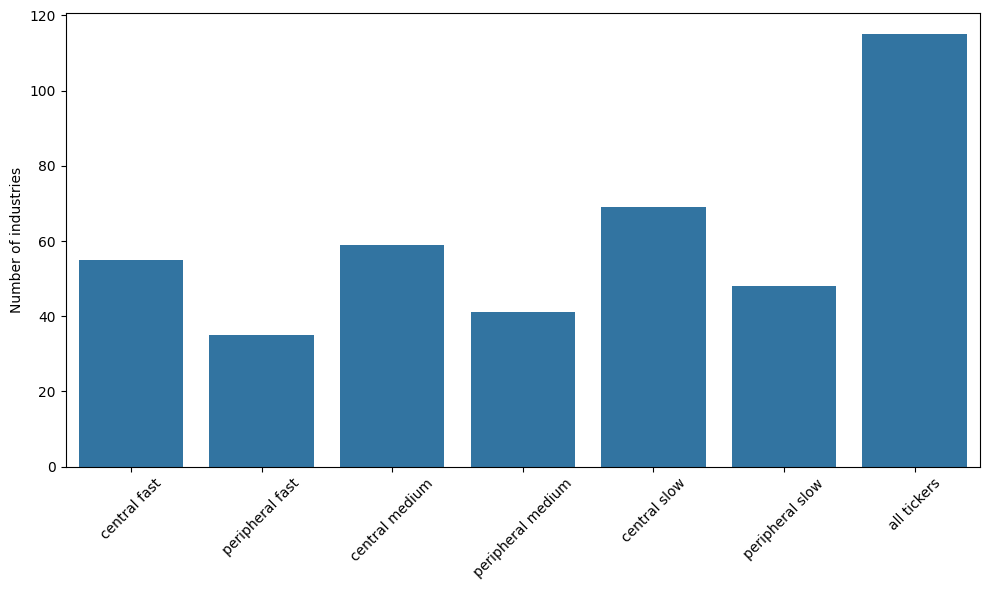

In [334]:
portfolios = final_df["portfolio"].unique()
temp = pd.DataFrame(columns=["n_industries"], index=portfolios)

for i in range(len(portfolios)):
    temp.loc[portfolios[i]] = final_df[final_df["portfolio"]==portfolios[i]]["Industry"].nunique()
temp.loc["all tickers"] = final_df["Industry"].nunique()

plot_df = temp.reset_index().rename(
    columns={"index": "portfolio"}
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_df,
    x="portfolio",
    y="n_industries"
)

plt.xticks(rotation=45)
plt.xlabel("")
plt.ylabel("Number of industries")
plt.tight_layout()

out_dir = "../../figures"
dpi = 300
out_path = Path(out_dir)
out_path.mkdir(parents=True, exist_ok=True)

filename = f"n_industries_barplot_{year}.png"
fig.savefig(out_path / filename, dpi=dpi, bbox_inches="tight")

plt.show()

## Função de boxplots

In [335]:
def plot_metric_boxplots(
    df,
    metric,
    portfolio_col="portfolio",
    log_scale=False,
    figsize=(15, 6),
    metric_name=None,
    showfliers=False,
    save=True,
    out_dir="../../figures",
    dpi=300
):
    cut_col = metric + "_cut"
    metric_label = metric_name if metric_name else metric
    title_left = metric_label + " by Portfolios"
    title_right = metric_label + " by Quantile Cuts"

    fig, ax = plt.subplots(1, 2, figsize=figsize)

    # Log scale
    if log_scale:
        ax[0].set_yscale("log")
        ax[1].set_yscale("log")
        metric_label = metric_label + " (Log Scale)"

    # Left plot
    sns.boxplot(
        data=df,
        x=portfolio_col,
        y=metric,
        showfliers=showfliers,
        ax=ax[0]
    )
    ax[0].tick_params(axis="x", rotation=45)
    ax[0].set_xlabel("")
    ax[0].set_ylabel(metric_label)

    # Right plot
    sns.boxplot(
        data=df,
        x=cut_col,
        y=metric,
        showfliers=showfliers,
        ax=ax[1]
    )
    ax[1].set_xticklabels([1, 2, 3, 4, 5, 6])
    ax[1].tick_params(axis="x", rotation=45)
    ax[1].set_xlabel("")
    ax[1].set_ylabel(metric_label)

    # Titles
    ax[0].set_title(title_left)
    ax[1].set_title(title_right)

    plt.tight_layout()

    # Save figure
    if save:
        out_path = Path(out_dir)
        out_path.mkdir(parents=True, exist_ok=True)

        filename = f"{metric}_boxplot.png"
        fig.savefig(out_path / filename, dpi=dpi, bbox_inches="tight")

    plt.show()

## Market Cap

C:\Users\groque\AppData\Local\Temp\ipykernel_17636\138943610.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([1, 2, 3, 4, 5, 6])


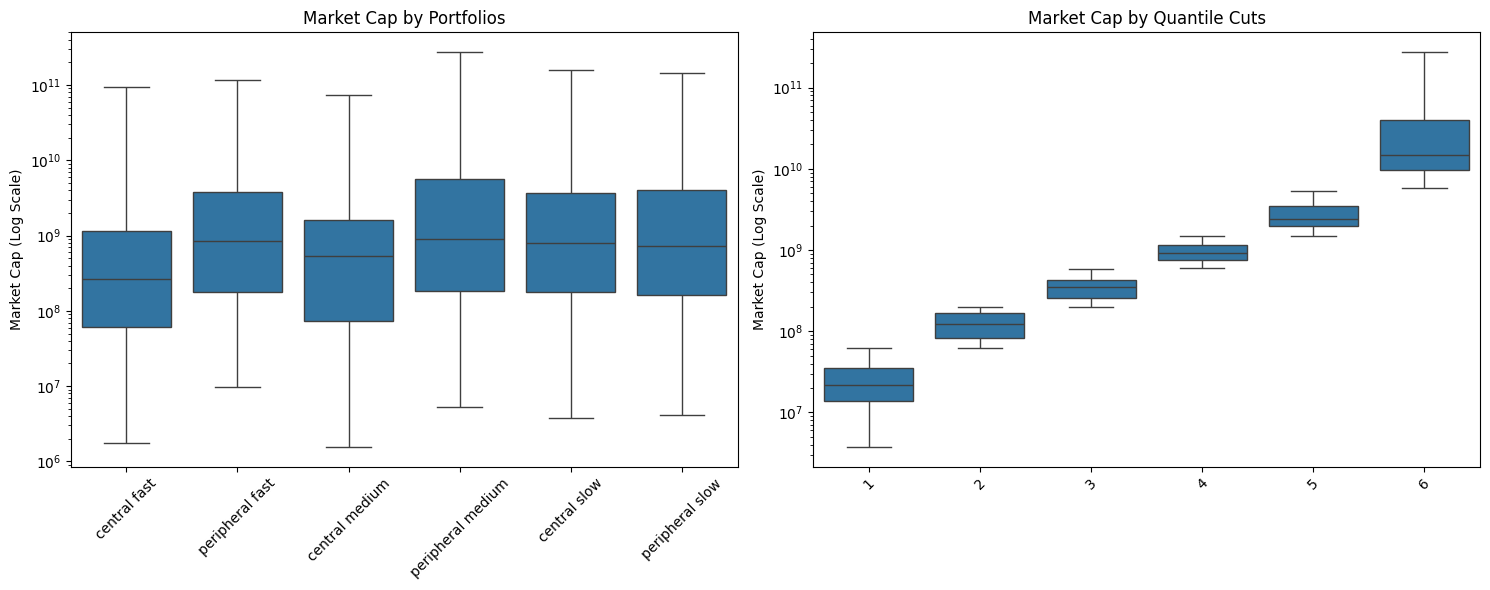

In [336]:
plot_metric_boxplots(
    df=final_df,
    metric="mcap_2019",
    log_scale=True,
    metric_name="Market Cap"
)

## Price to Earnings

C:\Users\groque\AppData\Local\Temp\ipykernel_17636\138943610.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([1, 2, 3, 4, 5, 6])


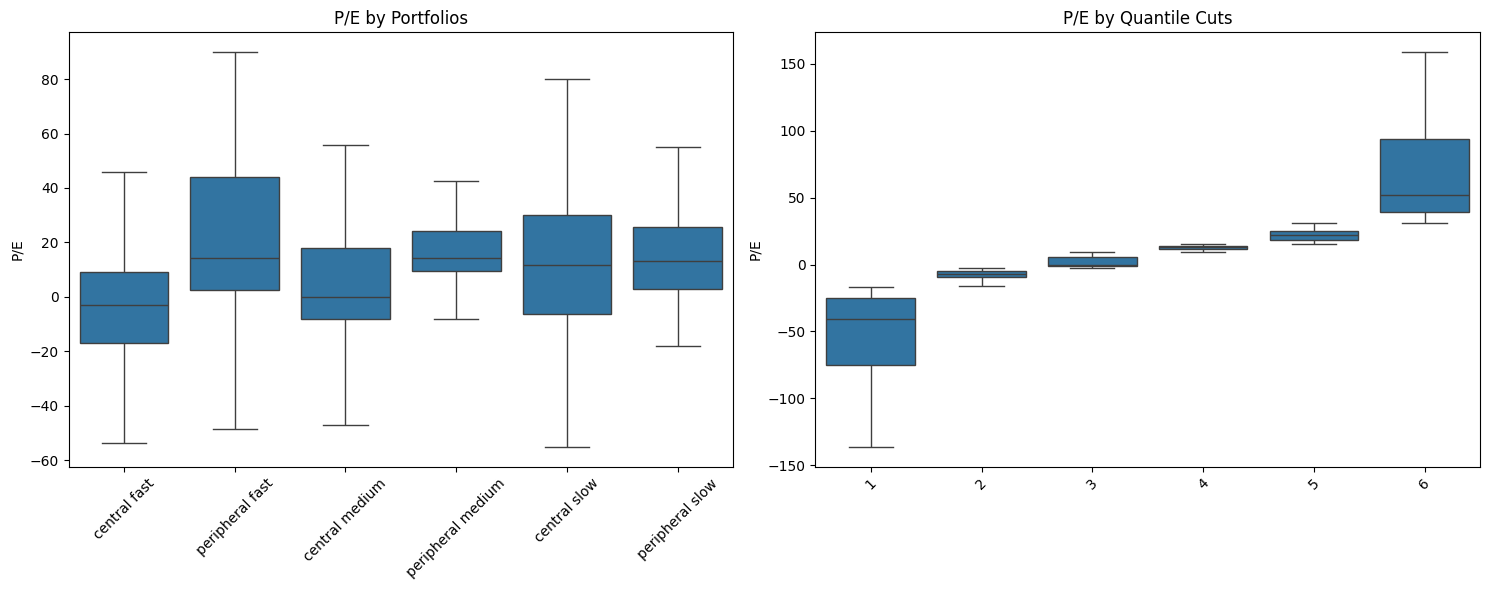

In [337]:
plot_metric_boxplots(
    df=final_df,
    metric="pe_2019",
    log_scale=False,
    metric_name="P/E"
)

### Dividend Yield

C:\Users\groque\AppData\Local\Temp\ipykernel_17636\138943610.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([1, 2, 3, 4, 5, 6])


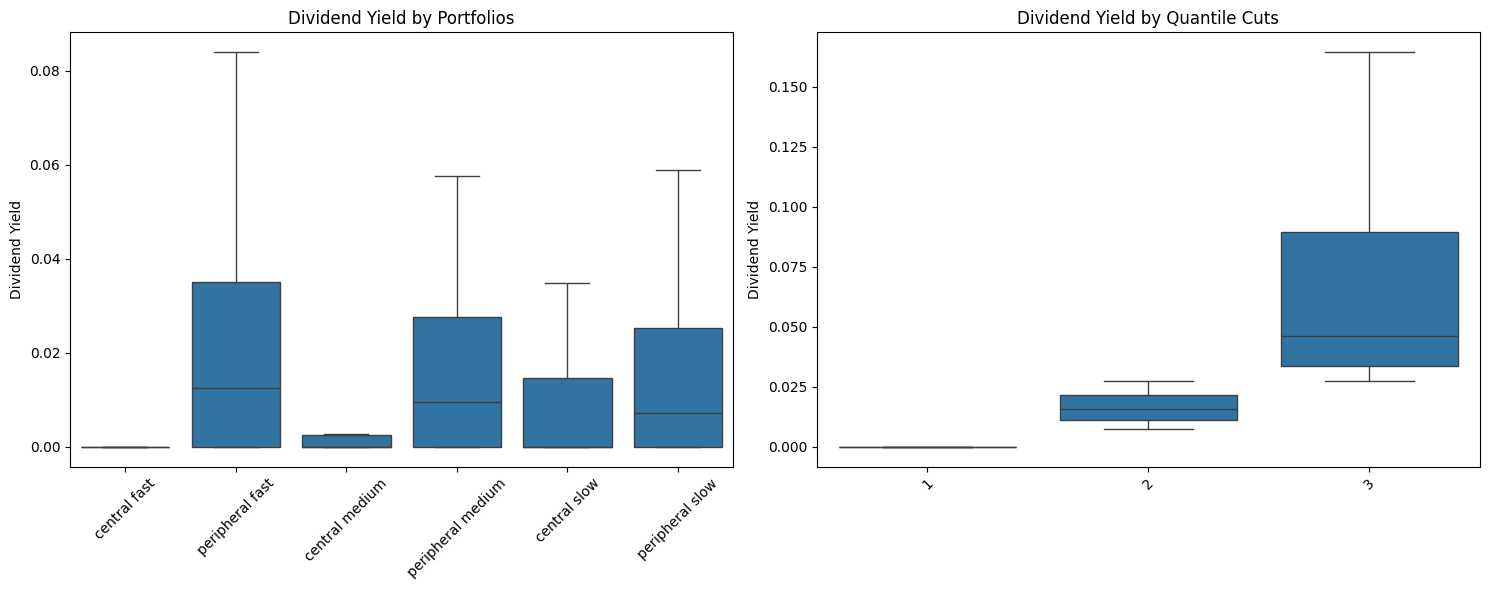

In [338]:
plot_metric_boxplots(
    df=final_df,
    metric="dy_2019",
    log_scale=False,
    metric_name="Dividend Yield"
)

### Piotroski Score

C:\Users\groque\AppData\Local\Temp\ipykernel_17636\138943610.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([1, 2, 3, 4, 5, 6])


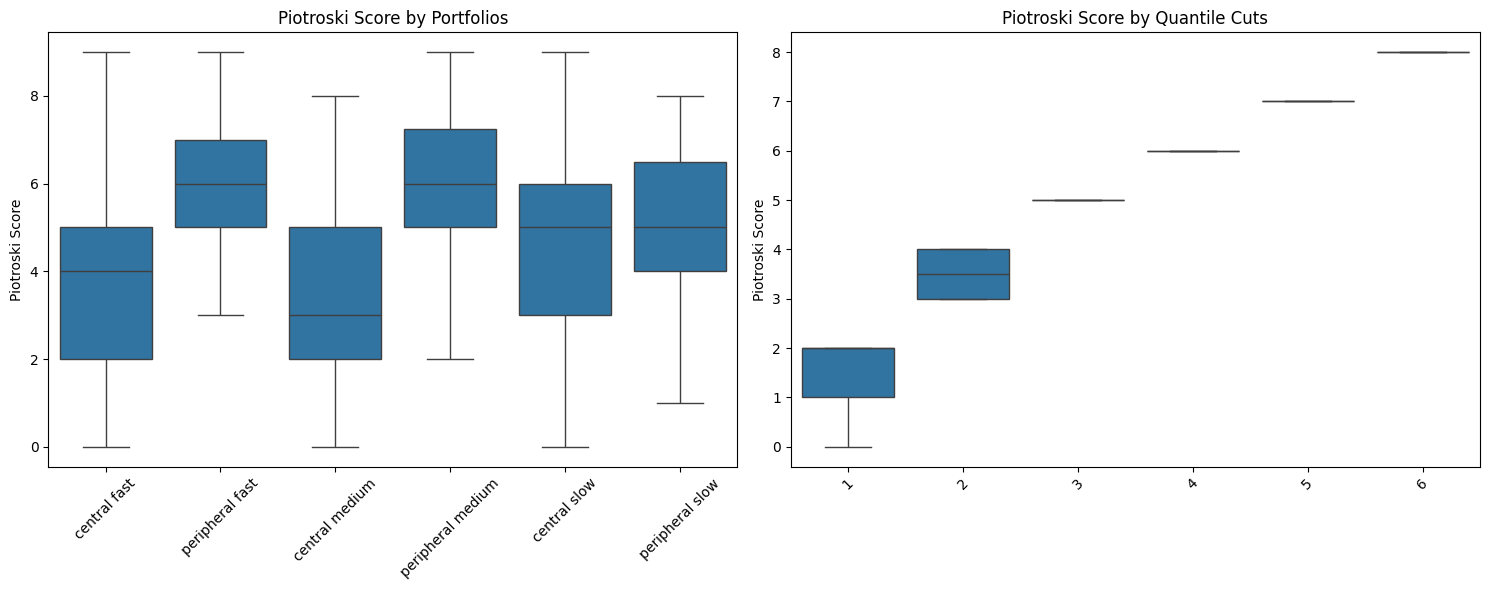

In [339]:
plot_metric_boxplots(
    df=final_df,
    metric="pscore_2019",
    log_scale=False,
    metric_name="Piotroski Score"
)

### Altman Z Score

C:\Users\groque\AppData\Local\Temp\ipykernel_17636\138943610.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([1, 2, 3, 4, 5, 6])


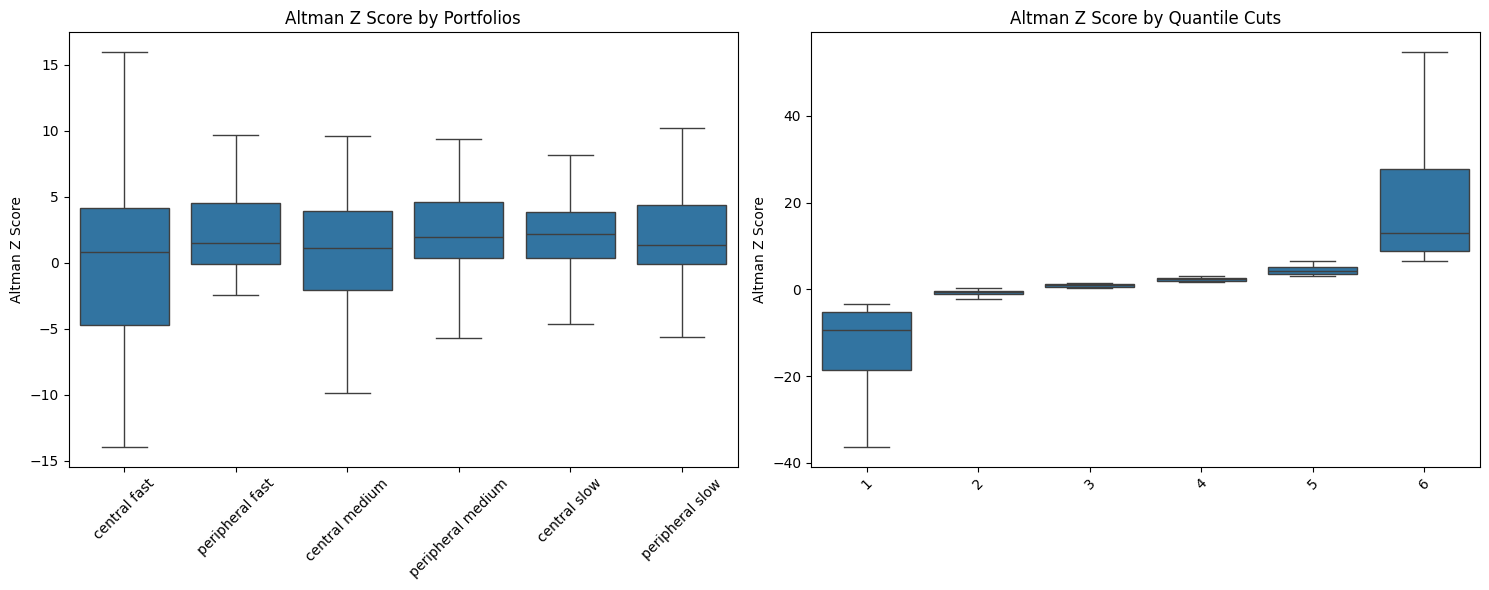

In [340]:
plot_metric_boxplots(
    df=final_df,
    metric="azscore_2019",
    log_scale=False,
    metric_name="Altman Z Score"
)

### Free Cash Flow Yield

C:\Users\groque\AppData\Local\Temp\ipykernel_17636\138943610.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([1, 2, 3, 4, 5, 6])


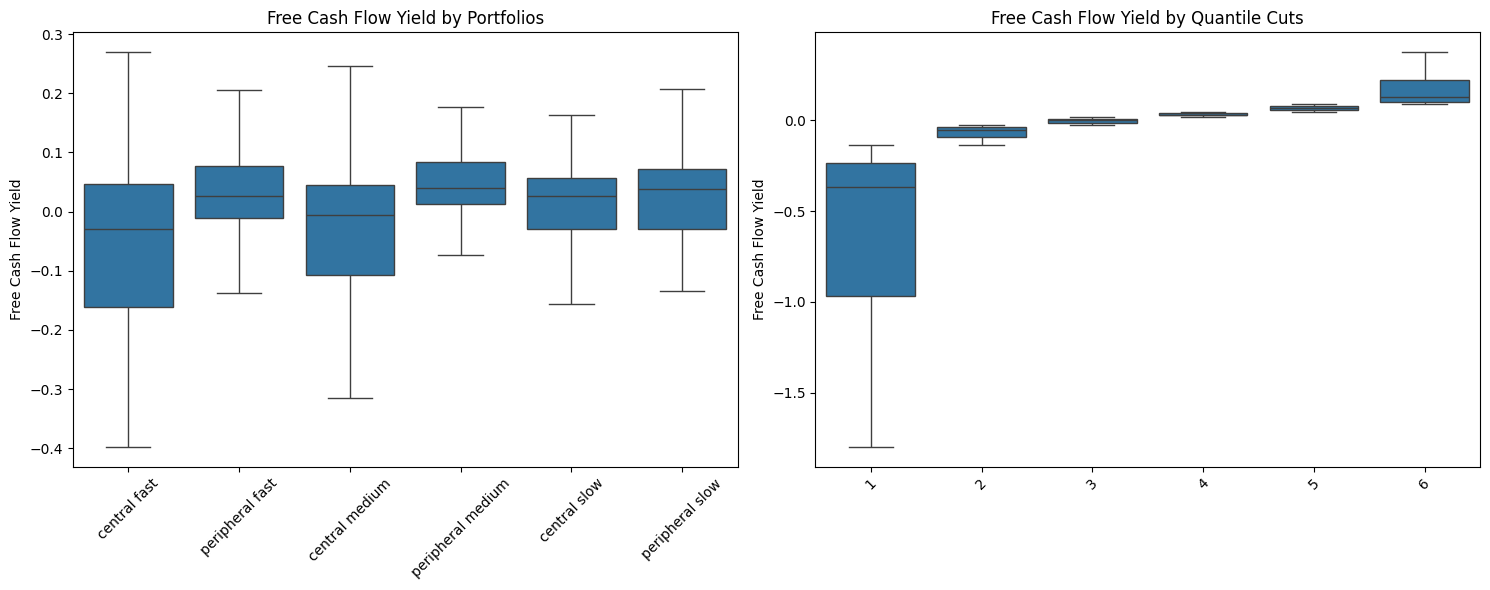

In [341]:
plot_metric_boxplots(
    df=final_df,
    metric="fcfyield_2019",
    log_scale=False,
    metric_name="Free Cash Flow Yield"
)

### Return on Invested Capital

C:\Users\groque\AppData\Local\Temp\ipykernel_17636\138943610.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([1, 2, 3, 4, 5, 6])


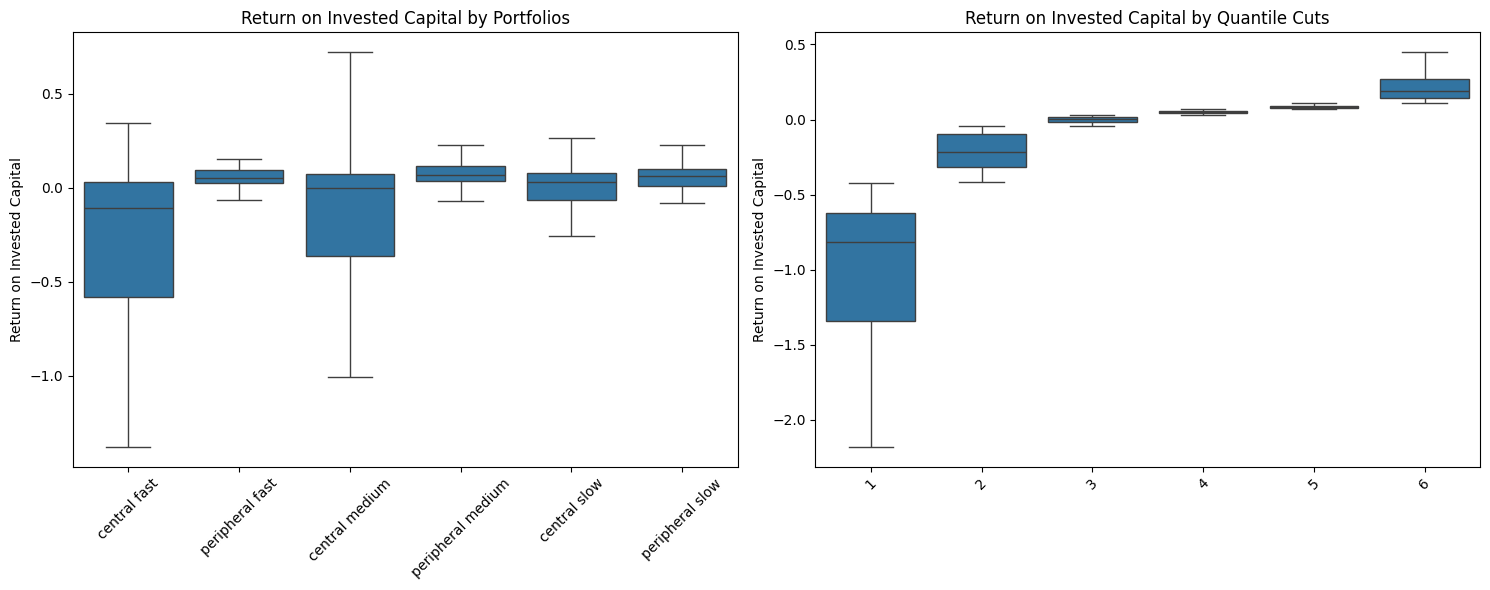

In [342]:
plot_metric_boxplots(
    df=final_df,
    metric="roic_2019",
    log_scale=False,
    metric_name="Return on Invested Capital"
)

### Revenue Growth

C:\Users\groque\AppData\Local\Temp\ipykernel_17636\138943610.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([1, 2, 3, 4, 5, 6])


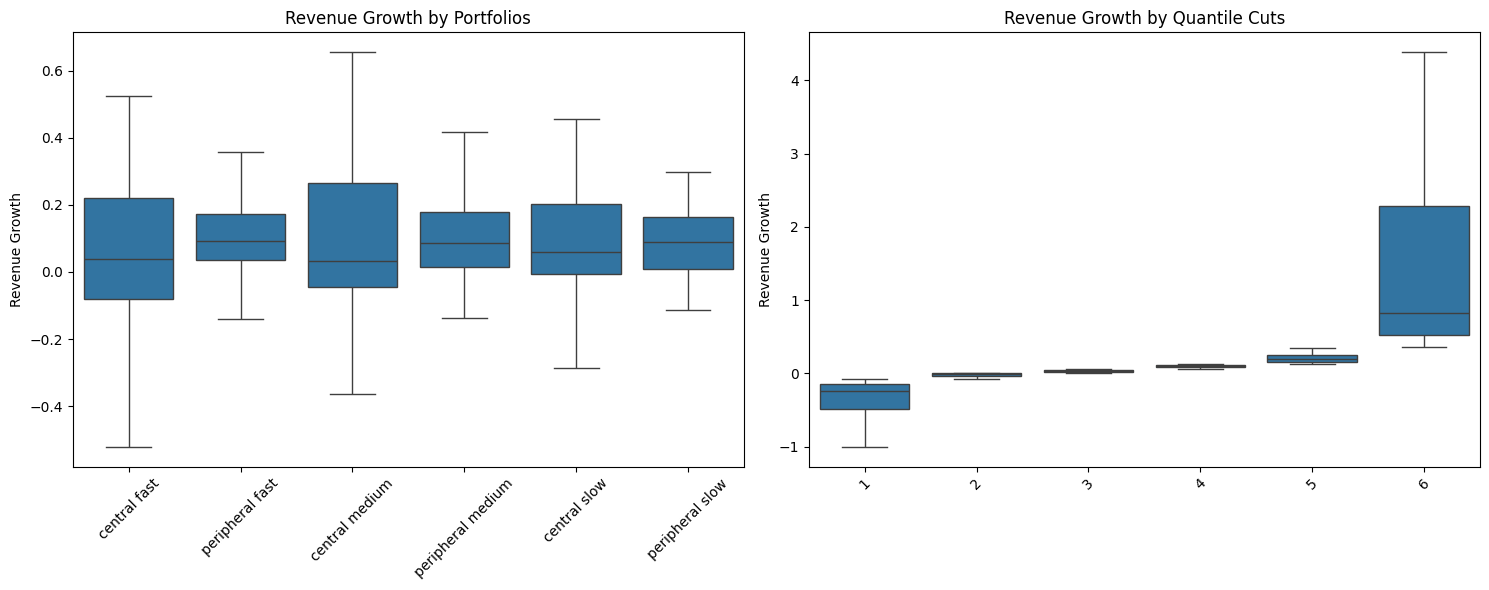

In [343]:
plot_metric_boxplots(
    df=final_df,
    metric="rg_2019",
    log_scale=False,
    metric_name="Revenue Growth"
)

### Net Debt / EBITDA

C:\Users\groque\AppData\Local\Temp\ipykernel_17636\138943610.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([1, 2, 3, 4, 5, 6])


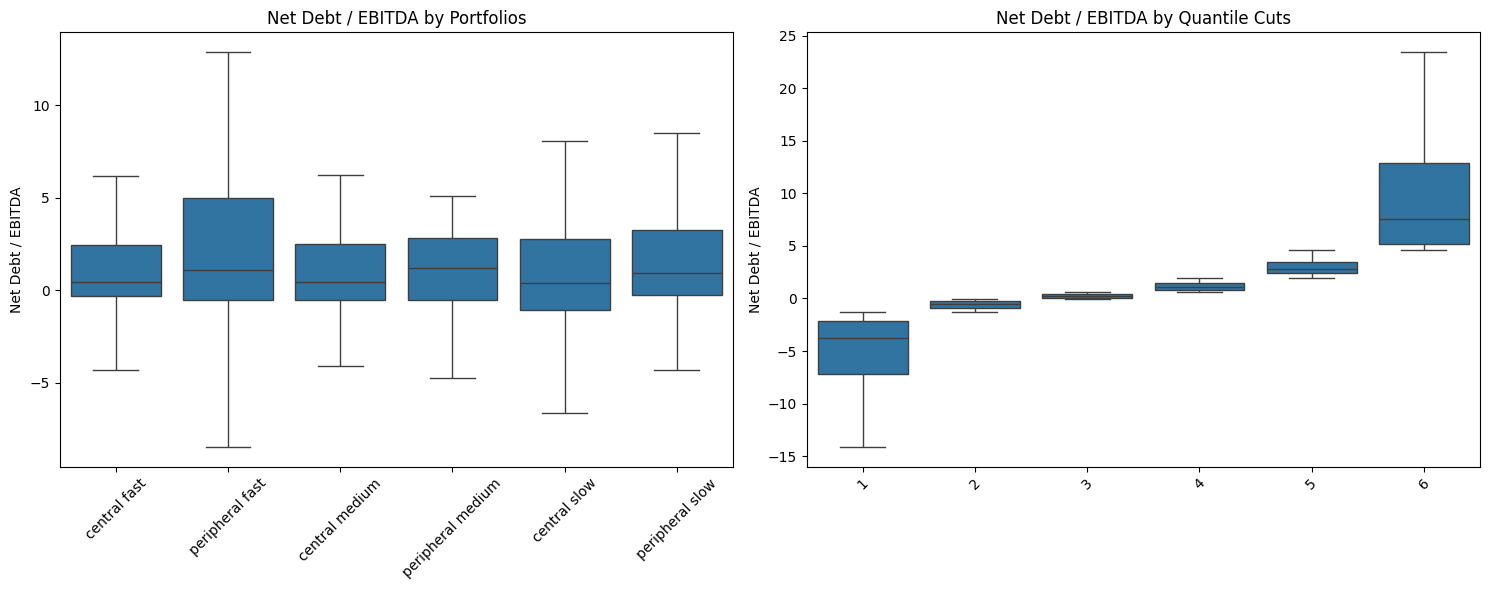

In [344]:
plot_metric_boxplots(
    df=final_df,
    metric="ndebitda_2019",
    log_scale=False,
    metric_name="Net Debt / EBITDA"
)

### Gross Profit Margin

C:\Users\groque\AppData\Local\Temp\ipykernel_17636\138943610.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([1, 2, 3, 4, 5, 6])


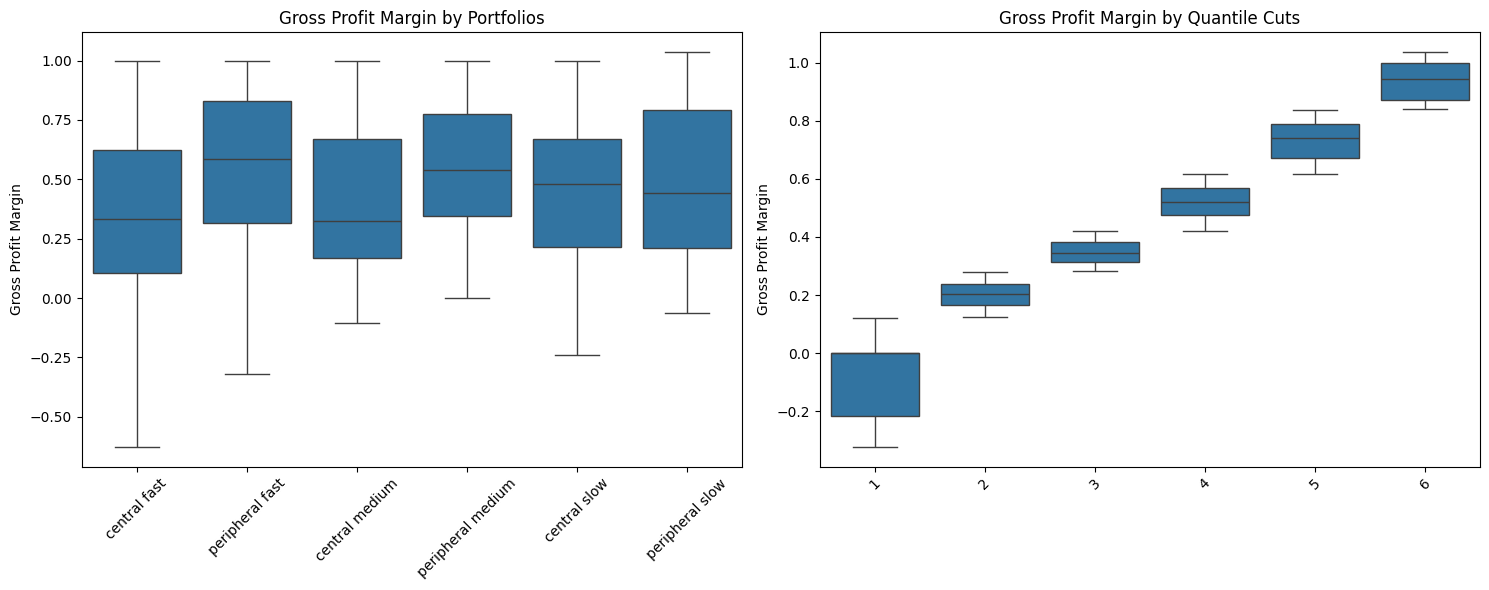

In [345]:
plot_metric_boxplots(
    df=final_df,
    metric="gpm_2019",
    log_scale=False,
    metric_name="Gross Profit Margin"
)

### EPS Diluted Growth

C:\Users\groque\AppData\Local\Temp\ipykernel_17636\138943610.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([1, 2, 3, 4, 5, 6])


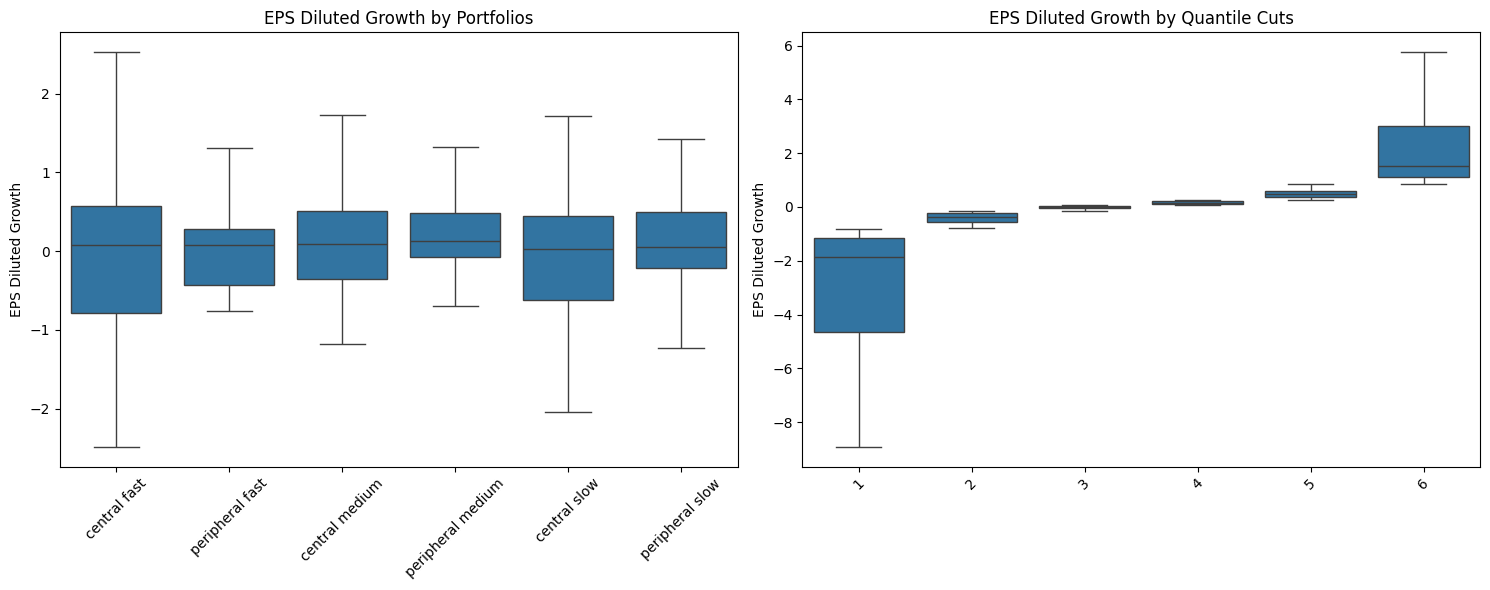

In [346]:
plot_metric_boxplots(
    df=final_df,
    metric="epsdg_2019",
    log_scale=False,
    metric_name="EPS Diluted Growth"
)

### Beta

C:\Users\groque\AppData\Local\Temp\ipykernel_17636\138943610.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([1, 2, 3, 4, 5, 6])


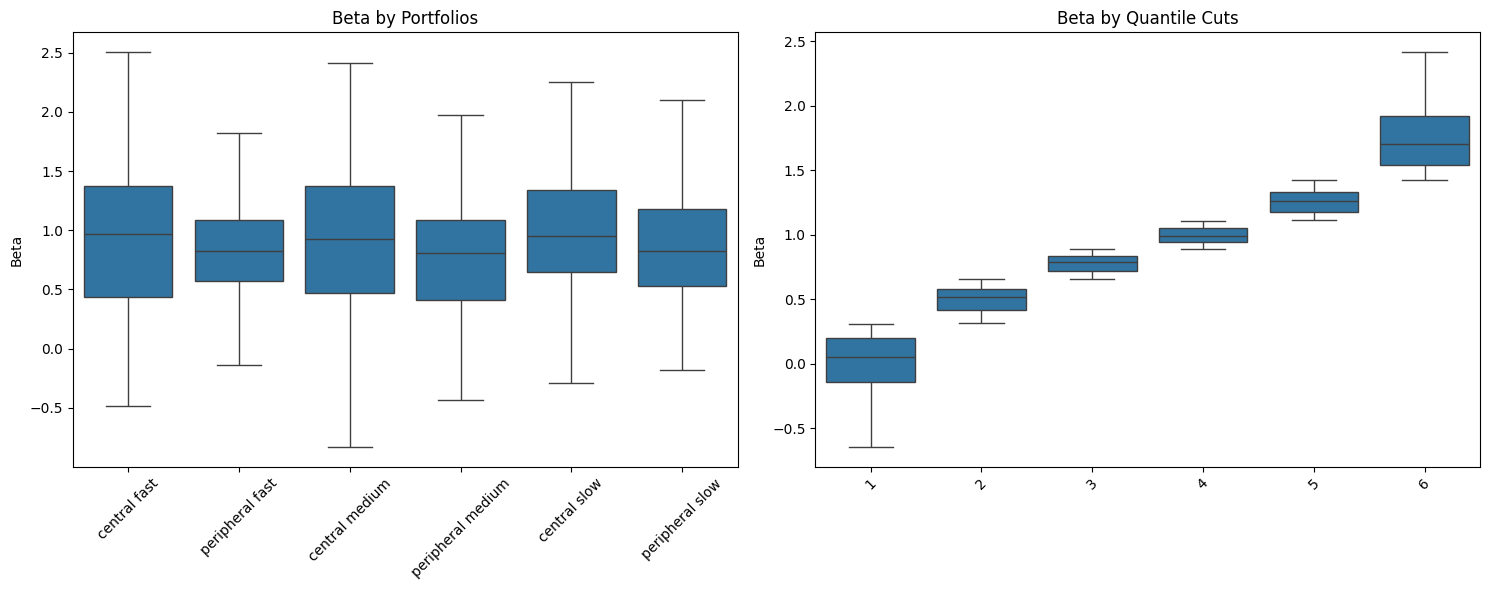

In [347]:
plot_metric_boxplots(
    df=final_df,
    metric="beta_2019",
    log_scale=False,
    metric_name="Beta"
)